<a href="https://colab.research.google.com/github/mamontoff2018-lgtm/google-colab/blob/main/MO6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from __future__ import division, print_function
import numpy as np
import pandas as pd
import scipy
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
%matplotlib inline

In [2]:
train_df = pd.read_csv('howpop_train.csv')
test_df = pd.read_csv('howpop_test.csv')
print('////////////////////////////////////////')
print(train_df.head())
print('////////////////////////////////////////')
print(test_df.head())

////////////////////////////////////////
                                url        domain  post_id  \
0  https://habrahabr.ru/post/18284/  habrahabr.ru    18284   
1  https://habrahabr.ru/post/18285/  habrahabr.ru    18285   
2  https://habrahabr.ru/post/18286/  habrahabr.ru    18286   
3  https://habrahabr.ru/post/18291/  habrahabr.ru    18291   
4  https://geektimes.ru/post/18294/  geektimes.ru    18294   

             published      author     flow  polling  content_len  \
0  2008-01-01 18:19:00      @Tapac  develop    False         4305   
1  2008-01-01 18:30:00  @DezmASter   design    False         7344   
2  2008-01-01 18:34:00  @DezmASter   design    False         8431   
3  2008-01-02 01:32:00    @Taoorus   design    False         5662   
4  2008-01-02 14:34:00    @dennydo      NaN    False         3706   

                                               title  comments  favs  views  \
0     Новогодний подарок блоггерам — WordPress 2.3.2         0     0    236   
1  Сумасшедши

In [4]:
train_df = pd.read_csv('howpop_train.csv')
test_df = pd.read_csv('howpop_test.csv')

print('////////////////////////////////////////')
print(train_df.head(1).T)
print('////////////////////////////////////////')
print(test_df.head(1).T)

////////////////////////////////////////
                                                               0
url                             https://habrahabr.ru/post/18284/
domain                                              habrahabr.ru
post_id                                                    18284
published                                    2008-01-01 18:19:00
author                                                    @Tapac
flow                                                     develop
polling                                                    False
content_len                                                 4305
title             Новогодний подарок блоггерам — WordPress 2.3.2
comments                                                       0
favs                                                           0
views                                                        236
votes_plus                                                   0.0
votes_minus                                      

In [5]:
print('Тестовый набор: \t', test_df.shape)
print('Обучающая выборка: \t', train_df.shape)

Тестовый набор: 	 (3990, 9)
Обучающая выборка: 	 (134137, 17)


In [6]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134137 entries, 0 to 134136
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   url               134137 non-null  object 
 1   domain            134137 non-null  object 
 2   post_id           134137 non-null  int64  
 3   published         134137 non-null  object 
 4   author            97657 non-null   object 
 5   flow              97048 non-null   object 
 6   polling           134137 non-null  bool   
 7   content_len       134137 non-null  int64  
 8   title             134137 non-null  object 
 9   comments          134137 non-null  int64  
 10  favs              134137 non-null  int64  
 11  views             134137 non-null  int64  
 12  votes_plus        133566 non-null  float64
 13  votes_minus       133566 non-null  float64
 14  views_lognorm     134137 non-null  float64
 15  favs_lognorm      134137 non-null  float64
 16  comments_lognorm  13

Ряд с датами столбца published
0   2008-01-01 18:19:00
1   2008-01-01 18:30:00
2   2008-01-01 18:34:00
3   2008-01-02 01:32:00
4   2008-01-02 14:34:00
Name: published, dtype: datetime64[ns]
Размер объекта Series:  (134137,)


<Axes: >

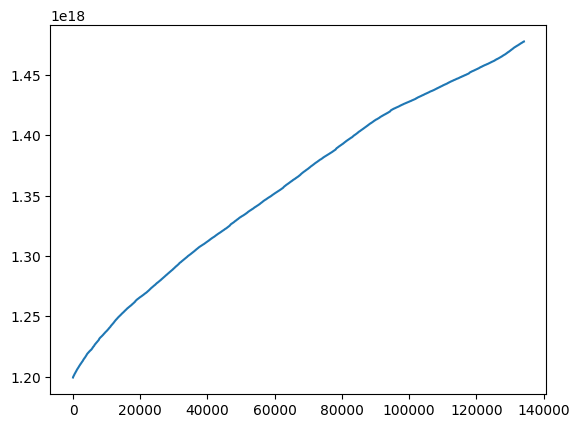

In [7]:
# копируем столбец данных published
ser_data = train_df['published'].apply(lambda ts: pd.to_datetime(ts))
print('Ряд с датами столбца published')
print(ser_data.head())
print('Размер объекта Series: ', ser_data.shape)
ser_data.apply(lambda el: el.value).plot()

In [10]:
corr = train_df.select_dtypes(include=[np.number]).corr()
corr

,post_id,content_len,comments,favs,views,votes_plus,votes_minus,views_lognorm,favs_lognorm,comments_lognorm
post_id,1.000000,0.241384,-0.147763,0.089313,0.132385,-0.187885,-0.235594,-0.010376,-0.005845,-0.001605
content_len,0.241384,1.000000,-0.023544,0.308194,0.204101,0.068779,-0.078686,0.246063,0.356481,0.073132
comments,-0.147763,-0.023544,1.000000,0.164166,0.290035,0.613961,0.457638,0.349568,0.278942,0.662740
favs,0.089313,0.308194,0.164166,1.000000,0.634304,0.416241,0.062877,0.456097,0.587982,0.263239
views,0.132385,0.204101,0.290035,0.634304,1.000000,0.396849,0.128654,0.585105,0.406782,0.326427
votes_plus,-0.187885,0.068779,0.613961,0.416241,0.396849,1.000000,0.464168,0.414232,0.449712,0.525081
votes_minus,-0.235594,-0.078686,0.457638,0.062877,0.128654,0.464168,1.000000,0.146609,0.088226,0.355458
views_lognorm,-0.010376,0.246063,0.349568,0.456097,0.585105,0.414232,0.146609,1.000000,0.688811,0.546530
favs_lognorm,-0.005845,0.356481,0.278942,0.587982,0.406782,0.449712,0.088226,0.688811,1.000000,0.479476
comments_lognorm,-0.001605,0.073132,0.662740,0.263239,0.326427,0.525081,0.355458,0.546530,0.479476,1.000000


In [11]:
corr[corr>0.9].replace({np.nan : ''})

,post_id,content_len,comments,favs,views,votes_plus,votes_minus,views_lognorm,favs_lognorm,comments_lognorm
post_id,1.0,,,,,,,,,
content_len,,1.0,,,,,,,,
comments,,,1.0,,,,,,,
favs,,,,1.0,,,,,,
views,,,,,1.0,,,,,
votes_plus,,,,,,1.0,,,,
votes_minus,,,,,,,1.0,,,
views_lognorm,,,,,,,,1.0,,
favs_lognorm,,,,,,,,,1.0,
comments_lognorm,,,,,,,,,,1.0


In [12]:
df = train_df.copy()
df['published'] = pd.to_datetime(df['published']).dt.year
ss = df['published'].value_counts()
print(ss.sort_index())

published
2008     7743
2009    10783
2010    13091
2011    15063
2012    15972
2013    15537
2014    16180
2015    23452
2016    16316
Name: count, dtype: int64


In [13]:
features = ['author', 'flow', 'domain','title']
train_size = int(0.7 * train_df.shape[0])
print('Размер исходного набора: ', len(train_df), \
      '\nРазмер обучающей подвыборки: ', train_size)

# отделяем признаки от целевой переменной
X, y = train_df.loc[:, features], train_df['favs_lognorm']
X_test = test_df.loc[:, features]
X_train, X_valid = X.iloc[:train_size, :], X.iloc[train_size:, :]
y_train, y_valid = y.iloc[:train_size], y.iloc[train_size:]

Размер исходного набора:  134137 
Размер обучающей подвыборки:  93895


In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_title = TfidfVectorizer(min_df=3, max_df=0.3, ngram_range=(1,3))

vx_train_title = vectorizer_title.fit_transform(X_train['title'])
print('vx_train_title.vocabulary_: ', len(vectorizer_title.vocabulary_))
vx_valid_title = vectorizer_title.transform(X_valid['title'])
print('vx_valid_title.vocabulary_: ', len(vectorizer_title.vocabulary_))
vx_test_title = vectorizer_title.transform(X_test['title'])
print('vx_test_title.vocabulary_: ', len(vectorizer_title.vocabulary_))

X_train_title = vectorizer_title.fit_transform(X_train['title'])
print('X_train_title.shape: ', X_train_title.shape)
X_valid_title = vectorizer_title.transform(X_valid['title'])
print('X_valid_title.shape: ', X_valid_title.shape)
X_test_title = vectorizer_title.transform(X_test['title'])
print('X_test_title.shape: ', X_test_title.shape)

vx_train_title.vocabulary_:  50624
vx_valid_title.vocabulary_:  50624
vx_test_title.vocabulary_:  50624
X_train_title.shape:  (93895, 50624)
X_valid_title.shape:  (40242, 50624)
X_test_title.shape:  (3990, 50624)


In [30]:
vectorizer_title.vocabulary_

{'новогодний': 31497,
 'подарок': 36257,
 'блоггерам': 14241,
 'wordpress': 12172,
 'новогодний подарок': 31499,
 'сумасшедшие': 45476,
 'яйца': 50489,
 'или': 22661,
 'сервис': 42745,
 'для': 18811,
 'отслеживания': 34225,
 'посетителей': 37373,
 'или сервис': 22833,
 'сервис для': 42751,
 'для отслеживания': 19413,
 'или сервис для': 22834,
 'сервис для отслеживания': 42753,
 'сглаживание': 42460,
 'шрифтов': 49862,
 'отрисовка': 34214,
 'сглаживание шрифтов': 42461,
 'почему': 37632,
 'мне': 28231,
 'не': 30755,
 'нравится': 31925,
 'iphone': 5951,
 'почему мне': 37659,
 'мне не': 28233,
 'не нравится': 30851,
 'всеобщая': 16456,
 'доступность': 20285,
 'действии': 18272,
 'чем': 49165,
 'суть': 45504,
 'проекта': 39310,
 'ru': 9541,
 'search': 9842,
 'запускается': 21584,
 'понедельник': 37201,
 'mobile': 7315,
 'выбор': 16759,
 'способа': 44575,
 'связи': 42437,
 'обзор': 32095,
 'под': 36147,
 'windows': 11973,
 'под windows': 36185,
 'онлайн': 33063,
 'банкинг': 13661,
 'оформле

In [35]:
vectorizer_title_ch = TfidfVectorizer(analyzer='char')

vx_train_title_ch = vectorizer_title_ch.fit_transform(X_train['title'])
print('vx_train_title_ch.vocabulary_: ', len(vectorizer_title_ch.vocabulary_))

vx_valid_title_ch = vectorizer_title_ch.transform(X_valid['title'])
print('vx_valid_title_ch.vocabulary_: ', len(vectorizer_title_ch.vocabulary_))

vx_test_title_ch = vectorizer_title_ch.transform(X_test['title'])
print('vx_test_title_ch.vocabulary_: ', len(vectorizer_title_ch.vocabulary_))

X_train_title_ch = vectorizer_title_ch.fit_transform(X_train['title'])
print('X_train_title_ch.shape: ', X_train_title_ch.shape)
X_valid_title_ch = vectorizer_title_ch.transform(X_valid['title'])
print('X_valid_title_ch.shape: ', X_valid_title_ch.shape)
X_test_title_ch = vectorizer_title_ch.transform(X_test['title'])
print('X_test_title_ch.shape: ', X_test_title_ch.shape)

vx_train_title_ch.vocabulary_:  218
vx_valid_title_ch.vocabulary_:  218
vx_test_title_ch.vocabulary_:  218
X_train_title_ch.shape:  (93895, 218)
X_valid_title_ch.shape:  (40242, 218)
X_test_title_ch.shape:  (3990, 218)


In [36]:
from sklearn.feature_extraction import DictVectorizer
vectorizer_feats = DictVectorizer()

tmp_dict_train = X_train[features].fillna('-').T.to_dict().values()
tmp_dict_valid = X_valid[features].fillna('-').T.to_dict().values()
tmp_dict_test = X_test[features].fillna('-').T.to_dict().values()

X_train_feats = vectorizer_feats.fit_transform(tmp_dict_train)
X_valid_feats = vectorizer_feats.transform(tmp_dict_valid)
X_test_feats = vectorizer_feats.transform(tmp_dict_test)

print(X_train_feats.shape)
print(X_valid_feats.shape)
print(X_test_feats.shape)

(93895, 111482)
(40242, 111482)
(3990, 111482)


In [37]:
# объединение матриц, построенных на предыдущих этапах
X_train_new = scipy.sparse.hstack([X_train_title, \
                                   X_train_feats, \
                                   X_train_title_ch])
X_valid_new = scipy.sparse.hstack([X_valid_title, \
                                   X_valid_feats, \
                                   X_valid_title_ch])
X_test_new = scipy.sparse.hstack([X_test_title, \
                                  X_test_feats, \
                                  X_test_title_ch])

print(X_train_new.shape)
print(X_valid_new.shape)
print(X_test_new.shape)

(93895, 162324)
(40242, 162324)
(3990, 162324)


In [38]:
%%time
model_1 = Ridge(alpha=.1, random_state=1)
model_1.fit(X_train_new, y_train)

train_preds1 = model_1.predict(X_train_new)
valid_preds1 = model_1.predict(X_valid_new)

print('Ошибка на трейне: ', mean_squared_error(y_train, train_preds1))
print('Ошибка на тесте: ', mean_squared_error(y_valid, valid_preds1))

Ошибка на трейне:  0.0033498668127804505
Ошибка на тесте:  0.6982987113454213
CPU times: user 43.8 s, sys: 32.2 ms, total: 43.8 s
Wall time: 38.6 s


In [39]:
%%time
model_2 = Ridge(alpha=1.0, random_state=1)
model_2.fit(X_train_new, y_train)

train_preds2 = model_2.predict(X_train_new)
valid_preds2 = model_2.predict(X_valid_new)

print('Ошибка на трейне: ', mean_squared_error(y_train, train_preds2))
print('Ошибка на тесте: ', mean_squared_error(y_valid, valid_preds2))

Ошибка на трейне:  0.08633264425668048
Ошибка на тесте:  0.6840061221431166
CPU times: user 15.2 s, sys: 15.5 ms, total: 15.2 s
Wall time: 9.23 s


In [40]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Загрузка датасета
cancer_data = load_breast_cancer()
dX = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
dy = pd.Series(cancer_data.target)

print("Количество объектов:", dX.shape[0])
print("Количество признаков:", dX.shape[1])
print("Количество классов:", len(dy.unique()))
print("Распределение классов: Доброкачественных (0):", sum(dy==0), ", Злокачественных (1):", sum(dy==1))

# Разделение данных
X_train, X_holdout, y_train, y_holdout = train_test_split(
    dX, dy, test_size=0.3, random_state=12
)

# Построение классификатора
tree = DecisionTreeClassifier(max_depth=5, random_state=21, max_features=10)
tree.fit(X_train, y_train)

# Оценка модели
tree_pred = tree.predict(X_holdout)
accur = accuracy_score(y_holdout, tree_pred)
print(f"Точность: {accur:.4f}")

# Экспорт дерева
export_graphviz(tree, out_file='cancer_tree.dot',
                feature_names=dX.columns, class_names=['Benign', 'Malignant'],
                filled=True, rounded=True)
os.system('dot -Tpng cancer_tree.dot -o cancer_tree.png')
print("Дерево сохранено в cancer_tree.png")

Количество объектов: 569
Количество признаков: 30
Количество классов: 2
Распределение классов: Доброкачественных (0): 212 , Злокачественных (1): 357
Точность: 0.9123
Дерево сохранено в cancer_tree.png


Анализ влияния max_depth на производительность:
max_depth | Mean Accuracy | MSE
        1 |    0.90159774 | 0.09840226
        2 |    0.90867794 | 0.09132206
        3 |    0.94906015 | 0.05093985
        4 |    0.92271303 | 0.07728697
        5 |    0.94207393 | 0.05792607
        6 |    0.93853383 | 0.06146617
        7 |    0.94022556 | 0.05977444
        8 |    0.94031955 | 0.05968045
        9 |    0.94031955 | 0.05968045
       10 |    0.94031955 | 0.05968045
       11 |    0.94031955 | 0.05968045
       12 |    0.94031955 | 0.05968045
       13 |    0.94031955 | 0.05968045
       14 |    0.94031955 | 0.05968045
       15 |    0.94031955 | 0.05968045
       16 |    0.94031955 | 0.05968045
       17 |    0.94031955 | 0.05968045
       18 |    0.94031955 | 0.05968045
       19 |    0.94031955 | 0.05968045


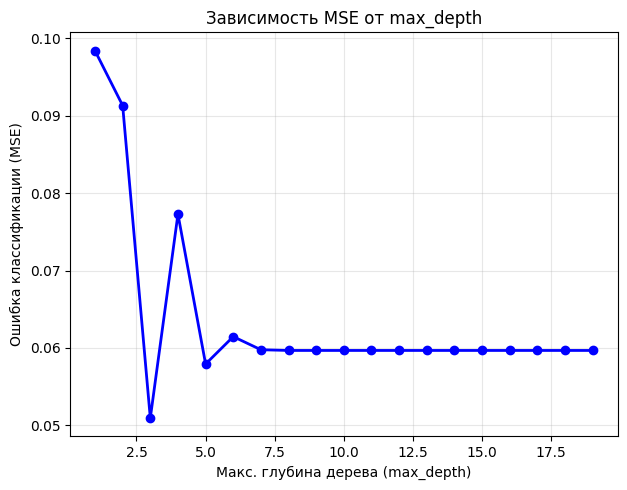


Оптимальные значения max_depth: [3]


In [43]:
from sklearn.model_selection import cross_val_score

d_list = list(range(1, 20))
cv_scores = []

print("Анализ влияния max_depth на производительность:")
print("max_depth | Mean Accuracy | MSE")

for d in d_list:
    tree = DecisionTreeClassifier(max_depth=d, random_state=21, max_features=10)
    scores = cross_val_score(tree, dX, dy, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())
    mse = 1 - scores.mean()
    print(f"{d:9d} | {scores.mean():13.8f} | {mse:.8f}")

# Вычисляем ошибку
MSE = [1 - x for x in cv_scores]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(d_list, MSE, 'b-o', linewidth=2, markersize=6)
plt.xlabel('Макс. глубина дерева (max_depth)')
plt.ylabel('Ошибка классификации (MSE)')
plt.title('Зависимость MSE от max_depth')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Поиск оптимума
d_min = min(MSE)
all_d_min = [d_list[i] for i in range(len(MSE)) if MSE[i] <= d_min]
print('\nОптимальные значения max_depth:', all_d_min)


Анализ влияния max_features на производительность:
max_features | Mean Accuracy | MSE
           1 |        0.9034 | 0.0966
           4 |        0.9333 | 0.0667
           7 |        0.9174 | 0.0826
          10 |        0.9402 | 0.0598
          13 |        0.9350 | 0.0650
          16 |        0.9262 | 0.0738
          19 |        0.9315 | 0.0685
          22 |        0.9438 | 0.0562
          25 |        0.9209 | 0.0791
          28 |        0.9069 | 0.0931


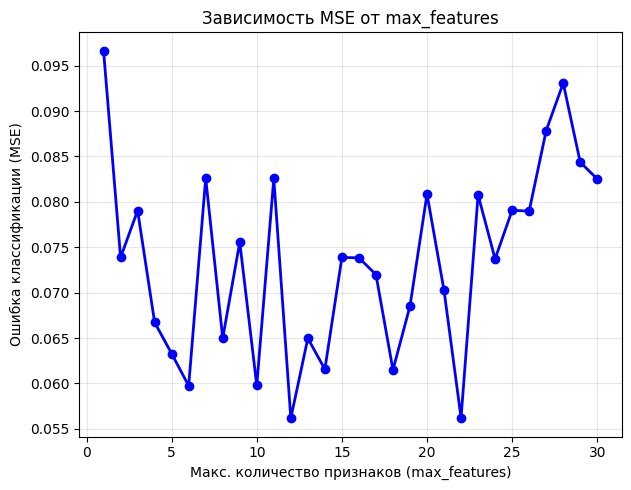


Оптимальные значения max_features: [12]


In [45]:
features_list = list(range(1, 31))
cv_scores_features = []

print("\nАнализ влияния max_features на производительность:")
print("max_features | Mean Accuracy | MSE")

for f in features_list:
    tree = DecisionTreeClassifier(max_depth=7, random_state=21, max_features=f)
    scores = cross_val_score(tree, dX, dy, cv=10, scoring='accuracy')
    cv_scores_features.append(scores.mean())
    mse = 1 - scores.mean()
    if f % 3 == 1:
        print(f"{f:12d} | {scores.mean():13.4f} | {mse:.4f}")

# Вычисляем ошибку
MSE_features = [1 - x for x in cv_scores_features]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(features_list, MSE_features, 'b-o', linewidth=2, markersize=6)
plt.xlabel('Макс. количество признаков (max_features)')
plt.ylabel('Ошибка классификации (MSE)')
plt.title('Зависимость MSE от max_features')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Поиск оптимума
f_min = min(MSE_features)
all_f_min = [features_list[i] for i in range(len(MSE_features)) if MSE_features[i] <= f_min]
print('\nОптимальные значения max_features:', all_f_min)

Fitting 10 folds for each of 260 candidates, totalling 2600 fits

Лучшее сочетание параметров: {'max_depth': 5, 'max_features': 13}
Лучший cross validation: 0.9508458646616541


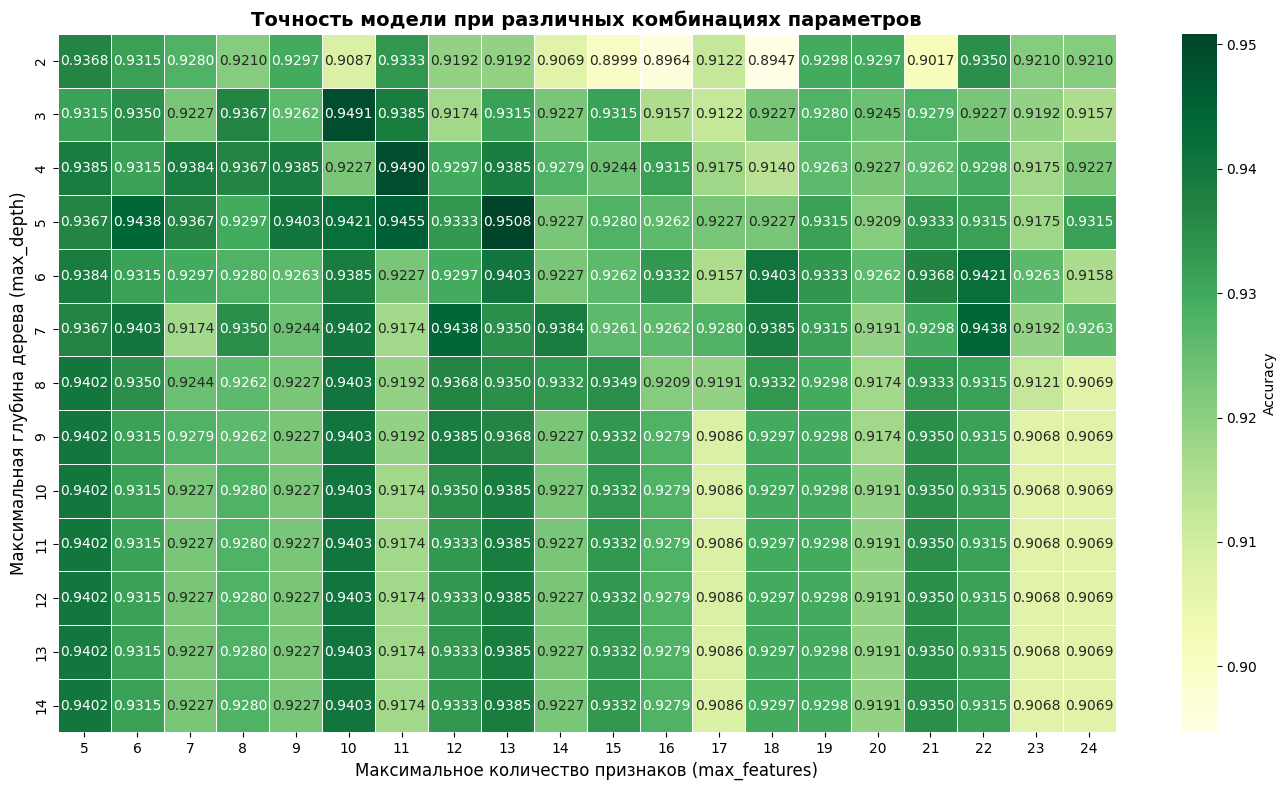


Выбранные параметры: max_depth=5, max_features=13


In [48]:
from sklearn.model_selection import GridSearchCV
import seaborn as sns

dtc = DecisionTreeClassifier(max_depth=10, random_state=21, max_features=15)

tree_params = {'max_depth': range(2, 15), 'max_features': range(5, 25)}
tree_grid = GridSearchCV(dtc, tree_params, cv=10, verbose=1, n_jobs=-1)
tree_grid.fit(dX, dy)

print('\nЛучшее сочетание параметров:', tree_grid.best_params_)
print('Лучший cross validation:', tree_grid.best_score_)

optimal_max_depth = tree_grid.best_params_['max_depth']
optimal_max_features = tree_grid.best_params_['max_features']

# Визуализация результатов GridSearchCV
results_df = pd.DataFrame(tree_grid.cv_results_)
results_pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_max_features'
)

plt.figure(figsize=(14, 8))
sns.heatmap(results_pivot, annot=True, fmt='.4f', cmap='YlGn',
            cbar_kws={'label': 'Accuracy'}, linewidths=0.5)
plt.xlabel('Максимальное количество признаков (max_features)', fontsize=12)
plt.ylabel('Максимальная глубина дерева (max_depth)', fontsize=12)
plt.title('Точность модели при различных комбинациях параметров', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nВыбранные параметры: max_depth={optimal_max_depth}, max_features={optimal_max_features}")


Точность оптимального классификатора: 0.9825
Оптимальное дерево сохранено в cancer_tree_optimal.png

Важность признаков (топ-10):
             Feature  Importance
     worst perimeter    0.702713
 mean concave points    0.073282
worst concave points    0.059212
        mean texture    0.044888
       worst texture    0.035072
        worst radius    0.032475
concave points error    0.026691
    worst smoothness    0.011933
     perimeter error    0.007504
     concavity error    0.003792


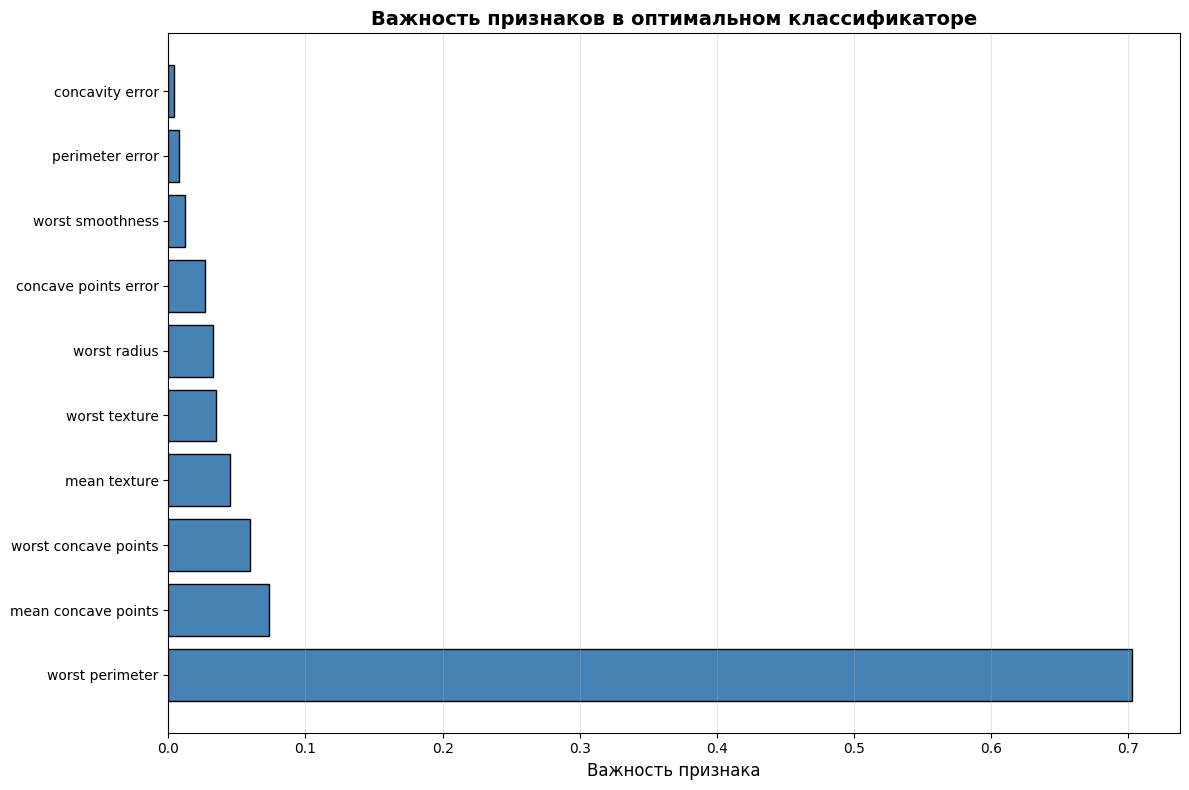

In [49]:
# Создание оптимального классификатора
optimal_tree = DecisionTreeClassifier(
    max_depth=optimal_max_depth,
    random_state=21,
    max_features=optimal_max_features
)
optimal_tree.fit(dX, dy)

# Проверка на тестовой выборке
y_pred = optimal_tree.predict(X_holdout)
accuracy = accuracy_score(y_holdout, y_pred)
print(f"Точность оптимального классификатора: {accuracy:.4f}")

export_graphviz(optimal_tree,
                feature_names=dX.columns,
                class_names=['Benign', 'Malignant'],
                out_file='cancer_tree_optimal.dot',
                filled=True, rounded=True, proportion=True)

os.system('dot -Tpng cancer_tree_optimal.dot -o cancer_tree_optimal.png')
print("Оптимальное дерево сохранено в cancer_tree_optimal.png")

# Анализ важности признаков
feature_importance = pd.DataFrame({
    'Feature': dX.columns,
    'Importance': optimal_tree.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nВажность признаков (топ-10):")
print(feature_importance.head(10).to_string(index=False))

plt.figure(figsize=(12, 8))
top_10 = feature_importance.head(10)
plt.barh(range(len(top_10)), top_10['Importance'].values, color='steelblue', edgecolor='black')
plt.yticks(range(len(top_10)), top_10['Feature'].values)
plt.xlabel('Важность признака', fontsize=12)
plt.title('Важность признаков в оптимальном классификаторе', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local

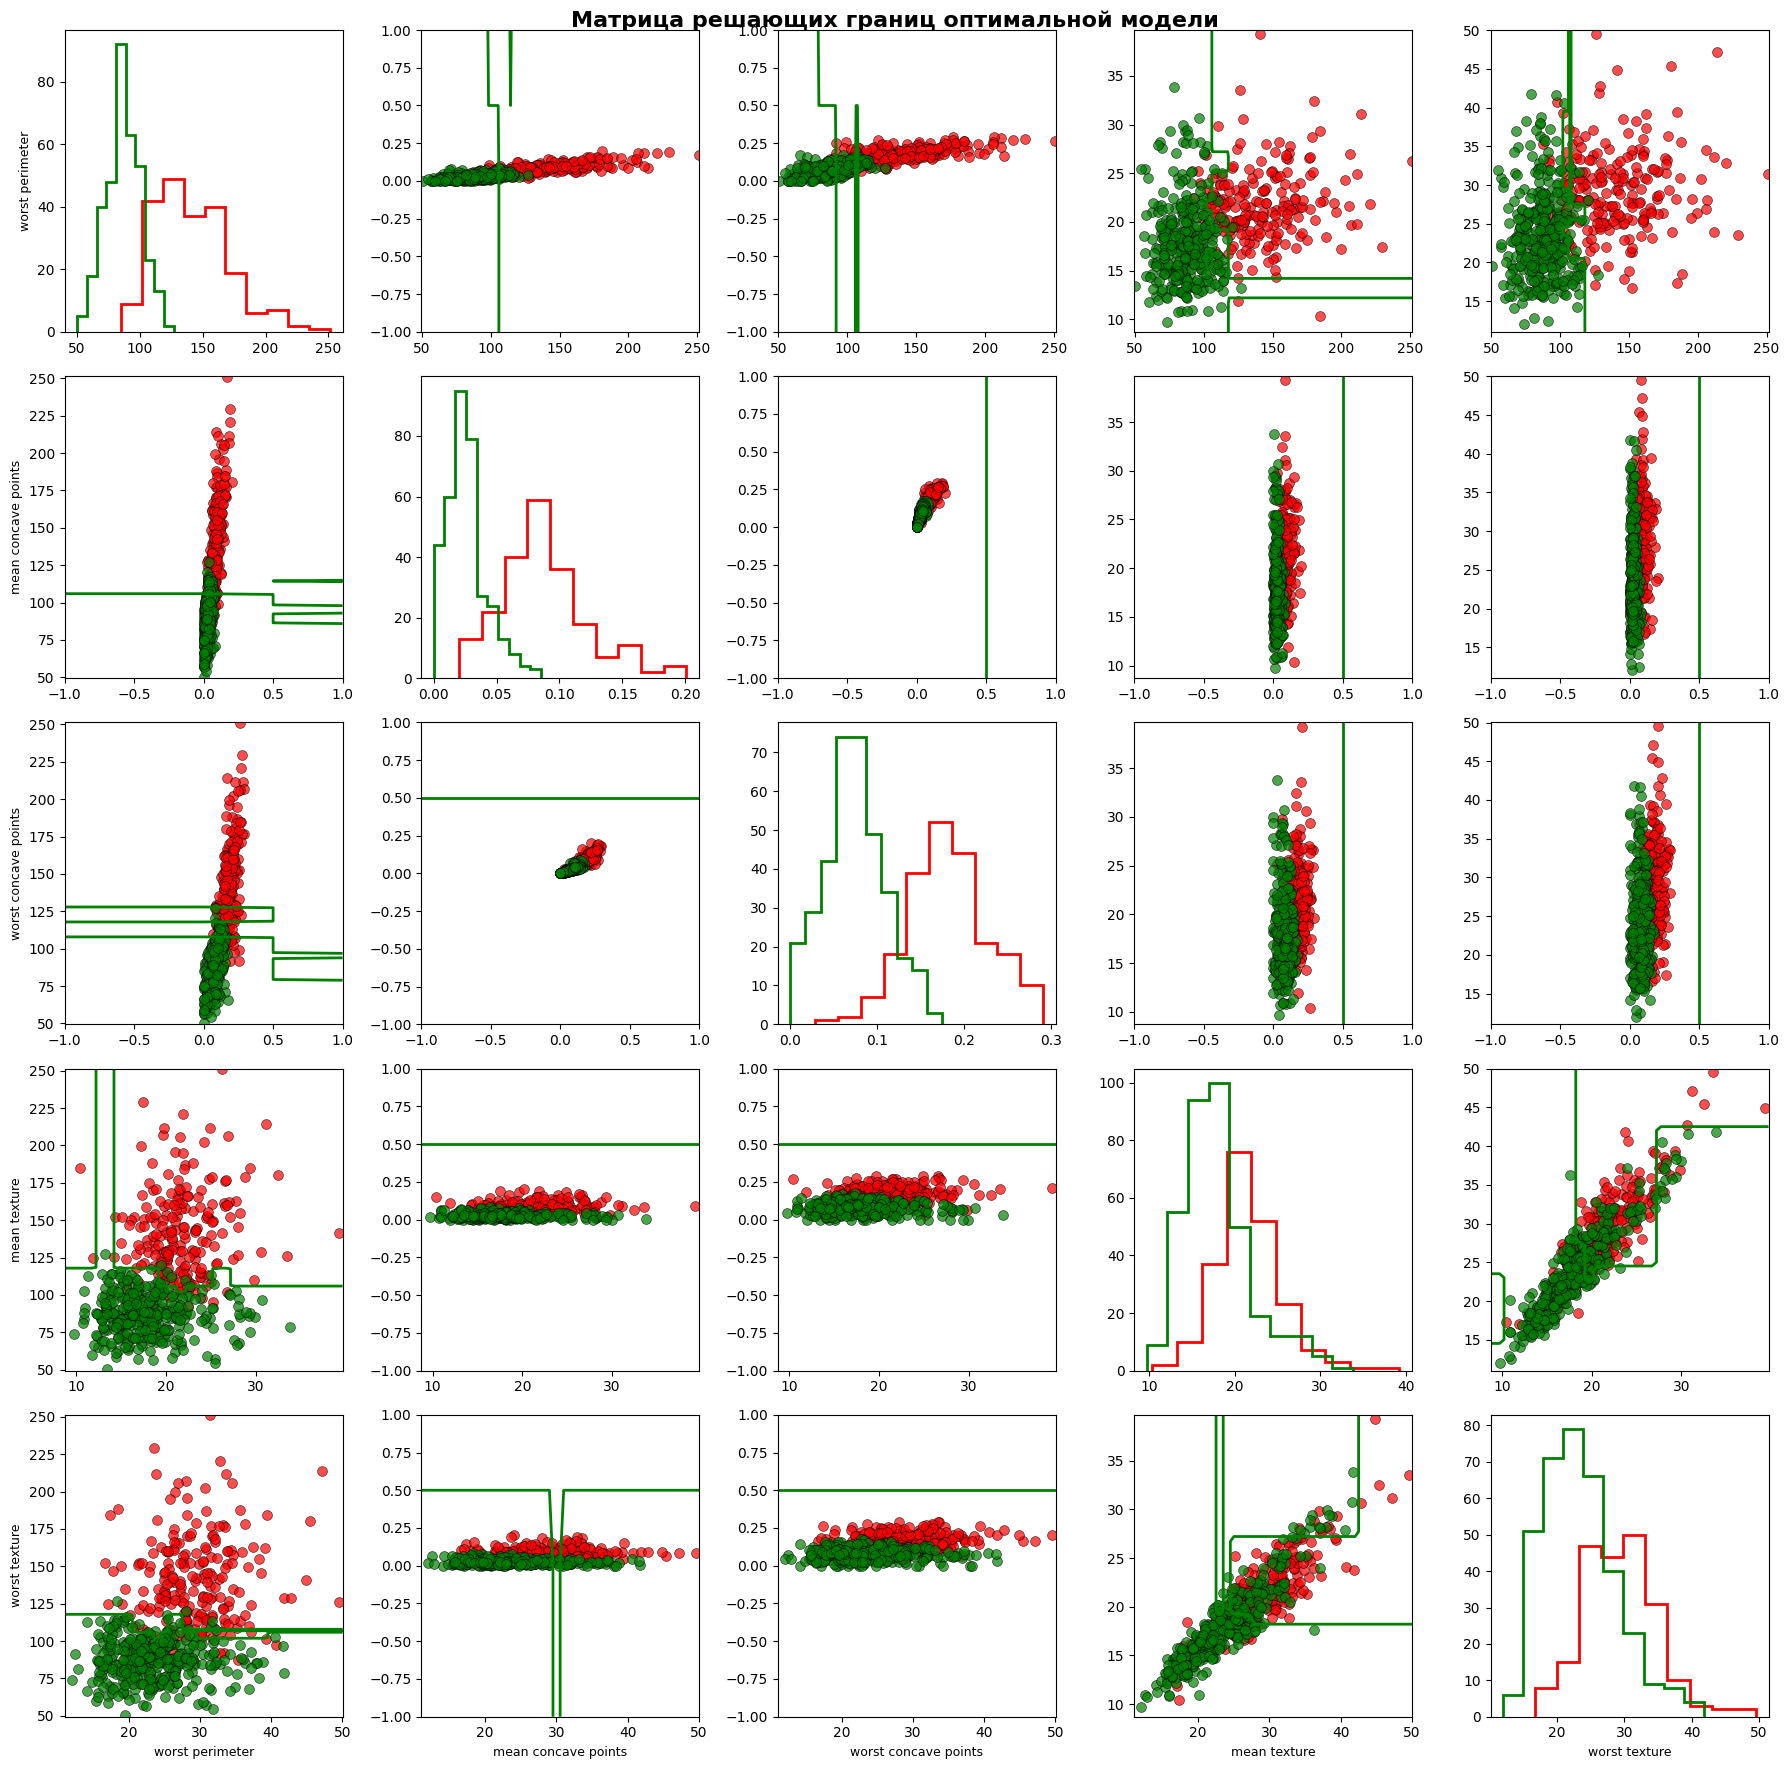

In [52]:
n_features = 5
top_features = feature_importance['Feature'].head(n_features).tolist()
feature_indices = [dX.columns.get_loc(feat) for feat in top_features]

f, places = plt.subplots(n_features, n_features, figsize=(18, 18))

plot_markers = ['red', 'green']
answers = dy.unique()

fmin = dX.iloc[:, feature_indices].min() - 1
fmax = dX.iloc[:, feature_indices].max() + 1
plot_step = 1

for i in range(0, n_features):
    for j in range(0, n_features):

        if(i != j):
            xx, yy = np.meshgrid(np.arange(fmin.iloc[i], fmax.iloc[i], plot_step),
                                 np.arange(fmin.iloc[j], fmax.iloc[j], plot_step))
            model = DecisionTreeClassifier(max_depth=optimal_max_depth, random_state=21, max_features=2)
            model.fit(dX.iloc[:, [feature_indices[i], feature_indices[j]]], dy)
            p = model.predict(np.c_[xx.ravel(), yy.ravel()])
            p = p.reshape(xx.shape)
            p[p == answers[0]] = 0
            p[p == answers[1]] = 1

            levels = np.arange(-0.5, 2, 1)
            places[i, j].contour(xx, yy, p, levels=levels, colors=plot_markers, linewidths=2)

        for id_answer in range(len(answers)):
            idx = np.where(dy == answers[id_answer])[0]
            if i == j:
                places[i, j].hist(dX.iloc[idx, feature_indices[i]],
                                  color=plot_markers[id_answer],
                                  histtype='step', linewidth=2)
            else:
                places[i, j].scatter(dX.iloc[idx, feature_indices[i]],
                                    dX.iloc[idx, feature_indices[j]],
                                    c=plot_markers[id_answer],
                                    s=50, alpha=0.7,
                                    edgecolors='black', linewidth=0.5)

            if j == 0:
                places[i, j].set_ylabel(top_features[i], fontsize=9)
            if i == n_features - 1:
                places[i, j].set_xlabel(top_features[j], fontsize=9)

plt.suptitle('Матрица решающих границ оптимальной модели', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()